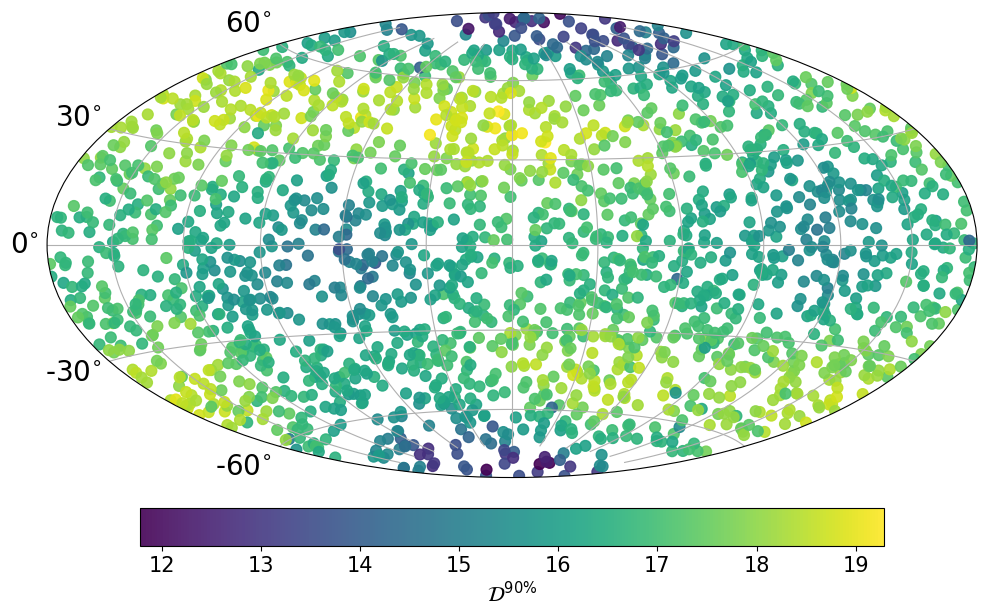

In [32]:

import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u
import numpy as np
import matplotlib
import matplotlib.mlab as mlab
from matplotlib.ticker import MultipleLocator

mplparams = {
    'text.usetex': True,  # use LaTeX for all text
    'axes.linewidth': 1,  # set axes linewidths to 0.5
    'axes.grid': False,  # add a grid
    'axes.labelweight': 'normal',
    'font.family': 'DejaVu Sans',
    'font.size': 22
    #'font.serif': 'Computer Modern Roman'
}
matplotlib.rcParams.update(mplparams)

# Parameters
f0 = 1000
size = (512, 64)
Tsft = 14400
seeds = range(400)
depth_file = f'sky2000pts_depth_at_p90_{f0}Hz.npz'

# Load depths at pdet = 0.9
depth_data = np.load(depth_file, allow_pickle=True)
depth_at_pdet_90 = depth_data['depth_at_pdet_90'] 
alpha = depth_data['alpha']
delta = depth_data['delta']
# Load RA and Dec from all seeds


alpha = np.array(alpha) 
delta = np.array(delta) 
alpha[alpha > np.pi] -= 2. * np.pi

# Filter out invalid depths
valid_mask = ~np.isnan(depth_at_pdet_90)
alpha = alpha[valid_mask]
delta = delta[valid_mask]
depths_valid = depth_at_pdet_90[valid_mask]

# Create the skymap
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='hammer')

# Scatter plot with depths as color
scatter = ax.scatter(ra_plot_rad, dec_plot_rad, c=depths_valid, s=60, alpha=0.9, cmap='viridis', 
                    vmin=np.min(depth_at_pdet_90[~np.isnan(depth_at_pdet_90)]), 
                    vmax=np.max(depth_at_pdet_90[~np.isnan(depth_at_pdet_90)]))

# Add smaller colorbar at the bottom
cbar = plt.colorbar(scatter, ax=ax, orientation='horizontal', pad=0.05, shrink=0.8)
cbar.set_label(r'$\mathcal{D}^{90\%}$', fontsize=15)
cbar.ax.tick_params(labelsize=15)  # Larger colorbar tick labels

# Customize the plot
ax.grid(True)

# Remove x-axis tick labels
ax.set_xticklabels([])

# Set Dec ticks with degree symbol
dec_ticks_deg = np.array([-60, -30, 0, 30, 60])
dec_ticks_rad = np.radians(dec_ticks_deg)
ax.set_yticks(dec_ticks_rad)
ax.set_yticklabels([f'{t:.0f}$^{{\\circ}}$' for t in dec_ticks_deg], fontsize=20)

# Save and show
plt.savefig(f'skymap_{f0}Hz.pdf')
plt.show()

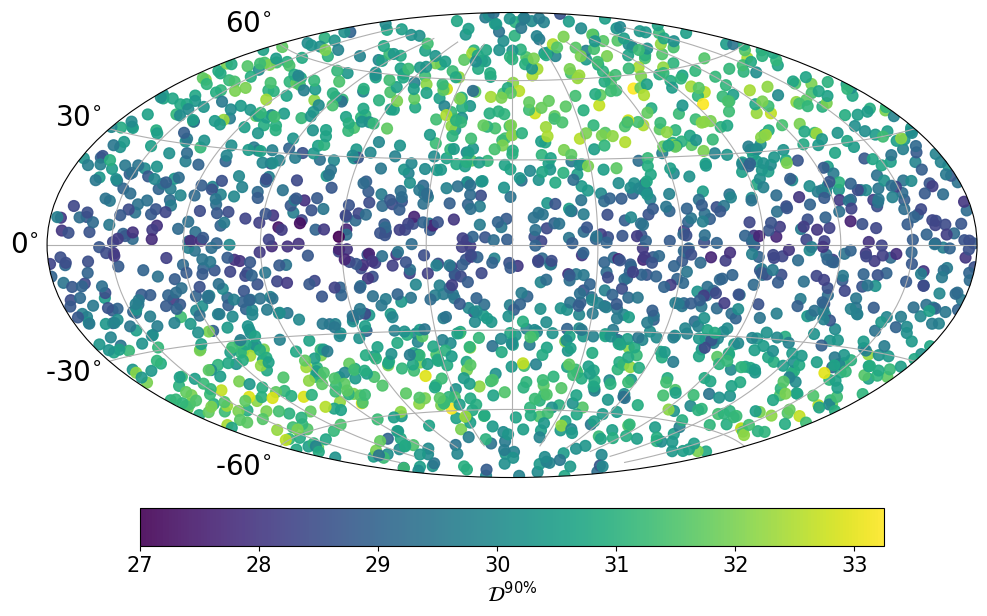

In [33]:
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u
import numpy as np

# Parameters
f0 = 20
size = (512, 64)
Tsft = 14400
seeds = range(400)
depth_file = f'sky2000pts_depth_at_p90_{f0}Hz.npz'

# Load depths at pdet = 0.9
depth_data = np.load(depth_file, allow_pickle=True)
depth_at_pdet_90 = depth_data['depth_at_pdet_90'] 
alpha = depth_data['alpha']
delta = depth_data['delta']
# Load RA and Dec from all seeds


alpha = np.array(alpha) 
delta = np.array(delta) 
alpha[alpha > np.pi] -= 2. * np.pi

# Filter out invalid depths
valid_mask = ~np.isnan(depth_at_pdet_90)
alpha = alpha[valid_mask]
delta = delta[valid_mask]
depths_valid = depth_at_pdet_90[valid_mask]

# Create the skymap
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='hammer')

# Scatter plot with depths as color
scatter = ax.scatter(ra_plot_rad, dec_plot_rad, c=depths_valid, s=60, alpha=0.9, cmap='viridis', 
                    vmin=np.min(depth_at_pdet_90[~np.isnan(depth_at_pdet_90)]), 
                    vmax=np.max(depth_at_pdet_90[~np.isnan(depth_at_pdet_90)]))

# Add smaller colorbar at the bottom
cbar = plt.colorbar(scatter, ax=ax, orientation='horizontal', pad=0.05, shrink=0.8)
cbar.set_label(r'$\mathcal{D}^{90\%}$', fontsize=15)
cbar.ax.tick_params(labelsize=15)  # Larger colorbar tick labels

# Customize the plot
ax.grid(True)

# Remove x-axis tick labels
ax.set_xticklabels([])

# Set Dec ticks with degree symbol
dec_ticks_deg = np.array([-60, -30, 0, 30, 60])
dec_ticks_rad = np.radians(dec_ticks_deg)
ax.set_yticks(dec_ticks_rad)
ax.set_yticklabels([f'{t:.0f}$^{{\\circ}}$' for t in dec_ticks_deg], fontsize=20)

# Save and show
plt.savefig(f'skymap_{f0}Hz.pdf')
plt.show()

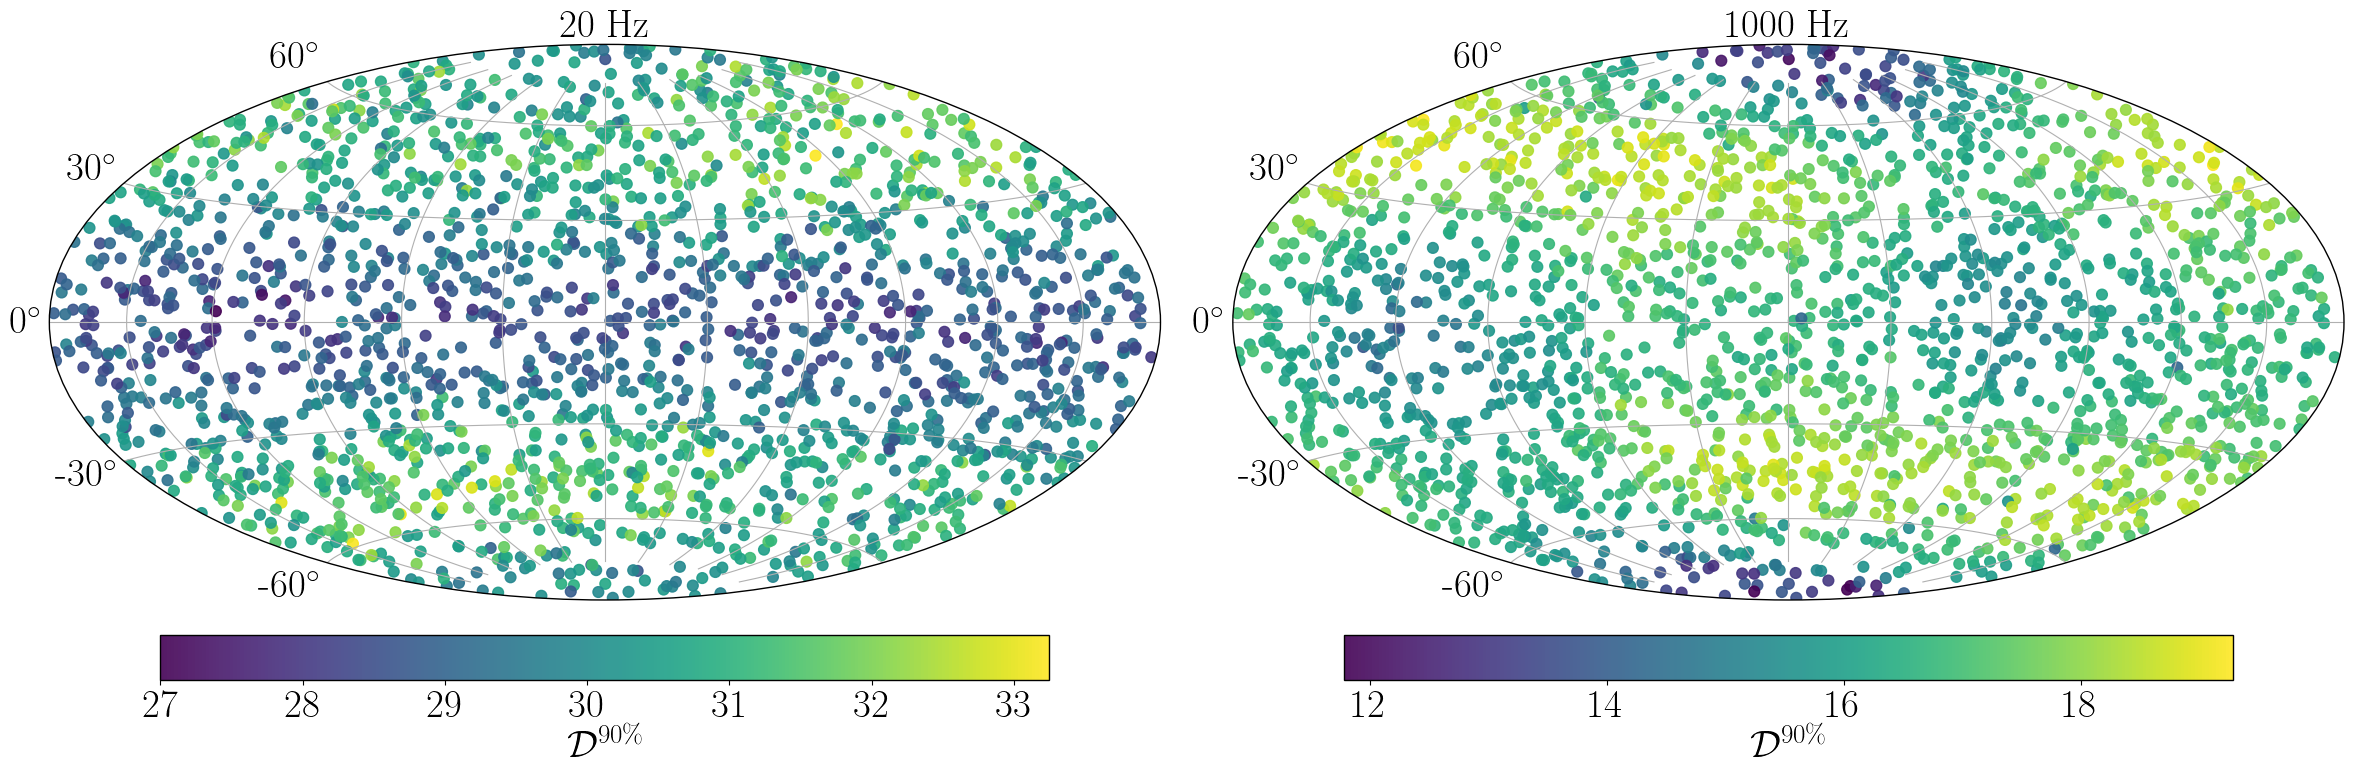

In [42]:
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u
import numpy as np
import matplotlib
import matplotlib.mlab as mlab
from matplotlib.ticker import MultipleLocator

mplparams = {
    'text.usetex': True,  # use LaTeX for all text
    'axes.linewidth': 1,  # set axes linewidths to 0.5
    'axes.grid': False,  # add a grid
    'axes.labelweight': 'normal',
    'font.family': 'DejaVu Sans',
    'font.size': 22
    #'font.serif': 'Computer Modern Roman'
}
matplotlib.rcParams.update(mplparams)



# Parameters
f0_values = [20, 1000]  # Frequencies in Hz
size = (512, 64)
Tsft = 14400
seeds = range(400)

# Create figure with two subplots
fig = plt.figure(figsize=(24, 8))  # Wide figure to accommodate two subplots

for i, f0 in enumerate(f0_values):
    # Load data
    depth_file = f'sky2000pts_depth_at_p90_{f0}Hz.npz'
    depth_data = np.load(depth_file, allow_pickle=True)
    depth_at_pdet_90 = depth_data['depth_at_pdet_90']
    alpha = depth_data['alpha']
    delta = depth_data['delta']

    # Process coordinates
    alpha = np.array(alpha)
    delta = np.array(delta)
    alpha[alpha > np.pi] -= 2. * np.pi  # Adjust RA to [-pi, pi]

    # Filter out invalid depths
    valid_mask = ~np.isnan(depth_at_pdet_90)
    alpha = alpha[valid_mask]
    delta = delta[valid_mask]
    depths_valid = depth_at_pdet_90[valid_mask]

    # Create subplot with Hammer projection
    ax = fig.add_subplot(1, 2, i+1, projection='hammer')
    
    # Scatter plot with depths as color
    scatter = ax.scatter(alpha, delta, c=depths_valid, s=60, alpha=0.9, 
                        cmap='viridis', 
                        vmin=np.min(depth_at_pdet_90[~np.isnan(depth_at_pdet_90)]), 
                        vmax=np.max(depth_at_pdet_90[~np.isnan(depth_at_pdet_90)]))

    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax, orientation='horizontal', pad=0.05, shrink=0.8)
    cbar.set_label(r'$\mathcal{D}^{90\%}$', fontsize=28)
    cbar.ax.tick_params(labelsize=28)

    # Customize the plot
    ax.grid(True)
    ax.set_xticklabels([])  # Remove RA tick labels
    dec_ticks_deg = np.array([-60, -30, 0, 30, 60])
    dec_ticks_rad = np.radians(dec_ticks_deg)
    ax.set_yticks(dec_ticks_rad)
    ax.set_yticklabels([f'{t:.0f}$^{{\\circ}}$' for t in dec_ticks_deg], fontsize=28)
    ax.set_title(f'{f0} Hz', fontsize=28)

# Adjust layout to prevent overlap
plt.tight_layout()

# Save and show
plt.savefig('skymap.pdf')
plt.show()

In [19]:
# Load RA and Dec from all seeds
f0 = 500
size = (512, 64)
Tsft = 14400
seeds = range(400)
#depth_file = 'sky2000pts_depth_at_p90_20Hz.npz'

# Load depths at pdet = 0.9
#depth_data = np.load(depth_file, allow_pickle=True)
#depth_at_pdet_90 = depth_data['depth_at_pdet_90']  # Shape: (6000,)

alpha = []
delta = []
for seed in seeds:
    filename = f'/scratch/kriles_root/kriles0/damoncht/unet_f/data/validation/skymap_{f0}Hz_H1L1_{size[0]}x{size[1]}_{Tsft}s_4c_traindata_n1000_seed{seed}.npz'
    data = np.load(filename, allow_pickle=True)
    params = data['params']
    for i in range(5):
        alpha.append(params[i*200, -2])  # Convert to degrees
        delta.append(params[i*200, -1])  # Dec in degrees

In [20]:
np.savez('sky2000pts_depth_at_p90_500Hz.npz', alpha=alpha, delta=delta)

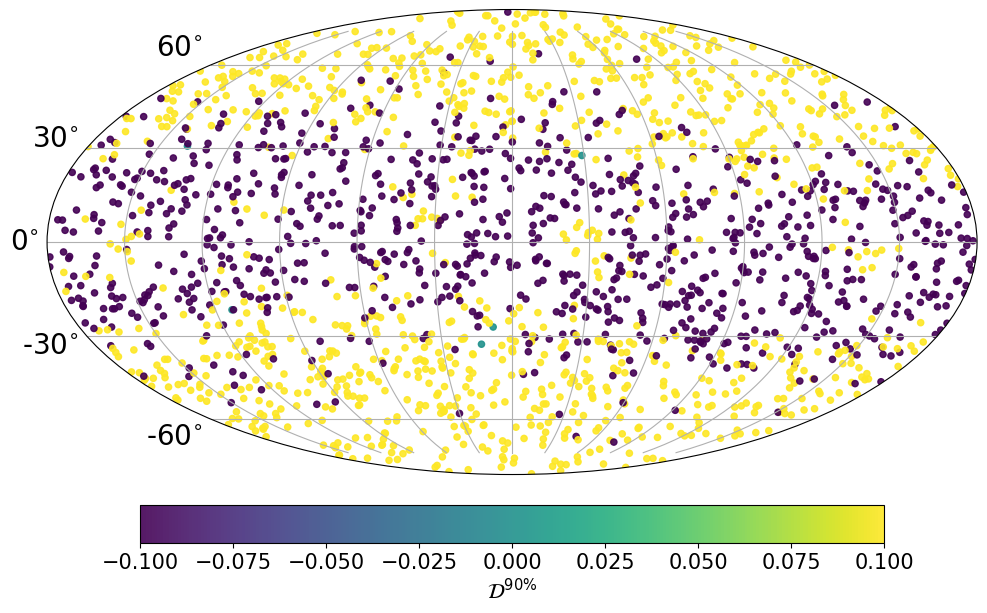

In [20]:
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u
import numpy as np

# Parameters
f0 = 500
size = (512, 64)
Tsft = 14400
seeds = range(400)
depth_file = 'sky2000pts_depth_at_p90_500Hz.npz'

# Load depths at pdet = 0.9
depth_data = np.load(depth_file, allow_pickle=True)
depth_at_pdet_90 = depth_data['depth_at_pdet_90']  # Shape: (6000,)

# Load RA and Dec from all seeds
alpha_deg = []
delta = []
for seed in seeds:
    filename = f'/scratch/kriles_root/kriles0/damoncht/unet_f/data/validation/skymap_{f0}Hz_H1L1_{size[0]}x{size[1]}_{Tsft}s_4c_traindata_n1000_seed{seed}.npz'
    data = np.load(filename, allow_pickle=True)
    params = data['params']
    for i in range(5):
        alpha_rad = params[i*200, -2]  # RA in radians
        alpha_deg.append(np.degrees(alpha_rad))  # Convert to degrees
        delta.append(params[i*200, -1])  # Dec in degrees

alpha_deg = np.array(alpha_deg)  # Shape: (6000,)
delta = np.array(delta)  # Shape: (6000,)

# Filter out invalid depths
valid_mask = ~np.isnan(depth_at_pdet_90)
ra_plot_rad = np.radians(180 - alpha_deg[valid_mask])  # RA in degrees -> radians, mirrored for astronomical convention
dec_plot_rad = delta[valid_mask]  # Dec in degrees -> radians
depths_valid = depth_at_pdet_90[valid_mask]

# Create the skymap
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='mollweide')

# Scatter plot with depths as color
scatter = ax.scatter(ra_plot_rad, dec_plot_rad, c=depths_valid, s=20, alpha=0.9, cmap='viridis', 
                    vmin=np.min(depth_at_pdet_90[~np.isnan(depth_at_pdet_90)]), 
                    vmax=np.max(depth_at_pdet_90[~np.isnan(depth_at_pdet_90)]))

# Add smaller colorbar at the bottom
cbar = plt.colorbar(scatter, ax=ax, orientation='horizontal', pad=0.05, shrink=0.8)
cbar.set_label(r'$\mathcal{D}^{90\%}$', fontsize=15)
cbar.ax.tick_params(labelsize=15)  # Larger colorbar tick labels

# Customize the plot
ax.grid(True)

# Remove x-axis tick labels
ax.set_xticklabels([])

# Set Dec ticks with degree symbol
dec_ticks_deg = np.array([-60, -30, 0, 30, 60])
dec_ticks_rad = np.radians(dec_ticks_deg)
ax.set_yticks(dec_ticks_rad)
ax.set_yticklabels([f'{t:.0f}$^{{\\circ}}$' for t in dec_ticks_deg], fontsize=20)

# Save and show
#plt.savefig('skymap_depth.pdf')
plt.show()